In [104]:
import pandas as pd

## Cara akses baris dan kolom
### Akses dengan kolom

In [ ]:
df = pd.DataFrame({
    "Nama": ["Adit", "Ardi", "Putra", "Ujun", "Ozon"],
    "Usia": [25, 32, 28, 35, 22],
    "Gaji": [5000000, 8500000, 6200000, 9100000, 4300000],
})

display(df["Gaji"]) # Ambil satu kolom
display(df[["Usia", "Gaji"]])

0    5000000
1    8500000
2    6200000
3    9100000
4    4300000
Name: Gaji, dtype: int64

,Usia,Gaji
0,25,5000000
1,32,8500000
2,28,6200000
3,35,9100000
4,22,4300000


### Akses dengan posisi

In [106]:
# Akses dengan posisi
display(isinstance(df.iloc[0], pd.Series))
display(df.iloc[0])
display(df.iloc[:, [1]]) # Pengambilan kolom dengan angka
display(df.iloc[1, 3:]) # Exclusive
display(df.iloc[::-1])

True

Nama       Adit
Usia         25
Gaji    5000000
Name: 0, dtype: object

,Usia
0,25
1,32
2,28
3,35
4,22


Series([], Name: 1, dtype: object)

,Nama,Usia,Gaji
4,Ozon,22,4300000
3,Ujun,35,9100000
2,Putra,28,6200000
1,Ardi,32,8500000
0,Adit,25,5000000


### Akses dengan label

In [107]:
# "Akses dengan label (label untuk akses tiap baris data) (default label kaya index, pake angka)"
display(isinstance(df.loc[1], pd.Series))
display(df.loc[1])
display(df.loc[4])
display(df.loc[2:3]) # Inclusive akhir
display(df.loc[2:3, ["Usia"]]) # Ambil kolom tertentu
display(df.loc[2:3, ["Usia"]])
df_labeled = df.set_index("Nama") # Ganti label dengan salah satu kolom
display(df_labeled)
df_resetted_label = df_labeled.reset_index() # label balik ke index
df_labeled = df
df.index = ["Anu1", "Anu2", "Anu3", "Anu4", "Anu5"] # Harus sama dengan jumlah baris data

True

Nama       Ardi
Usia         32
Gaji    8500000
Name: 1, dtype: object

Nama       Ozon
Usia         22
Gaji    4300000
Name: 4, dtype: object

,Nama,Usia,Gaji
2,Putra,28,6200000
3,Ujun,35,9100000


,Usia
2,28
3,35


,Usia
2,28
3,35


,Usia,Gaji
Nama,,
Adit,25,5000000
Ardi,32,8500000
Putra,28,6200000
Ujun,35,9100000
Ozon,22,4300000


In [ ]:
# assign data pada satu kolom pada tiap barisnya
df = pd.DataFrame({
    "Name": ["Udin", "Ucup", "Juki", "Ajid", "Ozon"],
    "Age": [25, 32, 45, 28, 55]
})

df["Age"] = 3
print(df)
df["Age"] = [10, 10, 32, 41, 45]
df

   Name  Age
0  Udin    3
1  Ucup    3
2  Juki    3
3  Ajid    3
4  Ozon    3


,Name,Age
0,Udin,10
1,Ucup,10
2,Juki,32
3,Ajid,41
4,Ozon,45


## Filter DataFrame dan Series
filtering pakai Array-Like dengan berisi boolean dan memiliki panjang sama dengan DataFrame/Series/nparray tersebut

In [109]:
df = pd.DataFrame({
    "Name": ["Udin", "Ucup", "Juki", "Ajid", "Ozon"],
    "Age": [25, 32, 45, 28, 55]
})
conditions = pd.Series([True, False, True, True, False])

print(df.Age > 50)
print(df[df.Age > 50], end="\n\n")
print(df[conditions], end="\n\n") # df[array-like] <- yg array-like yang panjangnya sama dengan jumlah baris data
print(df[[False, True, False, True, False]])

0    False
1    False
2    False
3    False
4     True
Name: Age, dtype: bool
   Name  Age
4  Ozon   55

   Name  Age
0  Udin   25
2  Juki   45
3  Ajid   28

   Name  Age
1  Ucup   32
3  Ajid   28


## Feature Binning dengan Pandas
1. Equals-Width

0    rendah
1    sedang
2    sedang
3    rendah
4    tinggi
5    sedang
6    sedang
7    rendah
8    tinggi
9    sedang
Name: Age, dtype: category
Categories (3, object): ['rendah' < 'sedang' < 'tinggi']
<class 'pandas.core.series.Series'>
Label-1     rendah
Label-2     sedang
Label-3     sedang
Label-4     rendah
Label-5     tinggi
Label-6     sedang
Label-7     sedang
Label-8     rendah
Label-9     tinggi
Label-10    sedang
Name: Age, dtype: category
Categories (3, object): ['rendah' < 'sedang' < 'tinggi']


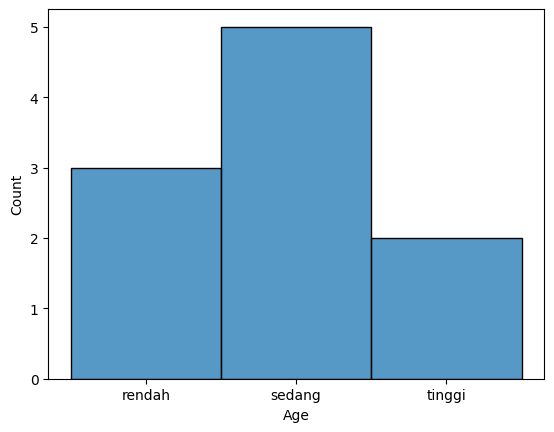

In [110]:
# Feature binning dengan metode Equals-Width
df = pd.DataFrame({
    "Age": [25, 32, 45, 28, 55, 38, 41, 29, 52, 36],
    "Visit": [3, 5, 8, 2, 12, 6, 7, 4, 10, 5]
})

anu = pd.cut(df["Age"], bins=[0, 30, 50, 100], labels=["rendah", "sedang", "tinggi"])
print(anu)
print(type(anu))

# Ganti label angka jadi teks
anu.index = [f"Label-{i}" for i in range(1, 11)]
print(anu)

import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(anu)
plt.show()

2. Equals-Frequency

0    rendah
1    sedang
2    tinggi
3    rendah
4    tinggi
5    sedang
6    tinggi
7    rendah
8    tinggi
9    sedang
Name: Age, dtype: category
Categories (3, object): ['rendah' < 'sedang' < 'tinggi']


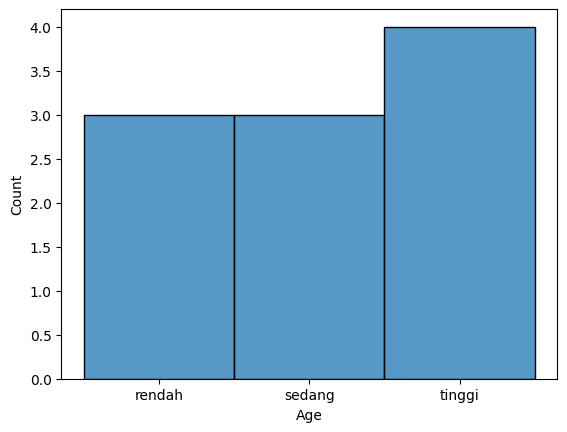

In [111]:
# pakai pd.qcut() untuk bining dengan metode Equals-Frequency
group = pd.qcut(df['Age'], q=3, labels=["rendah", "sedang", "tinggi"])
print(group)

import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(group)
plt.show()

### Menghitung korelasi feature

In [112]:
data = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?output=csv')
number_cols = data.select_dtypes(include='number').columns
pearson_corelation = data[number_cols].corr(method='pearson') # default, hitung hubungan linear
spearman_corelation = data[number_cols].corr(method='spearman')
kendall_corelation = data[number_cols].corr(method='kendall')
# tips: kalo kolom kategorial nominal (tidak bisa diurutkan), jangan dihitung korelasi kolomnya

print(isinstance(pearson_corelation, pd.DataFrame))
# print(pearson_corelation.columns)
# print(pearson_corelation.index)
print(pearson_corelation.loc["CustomerAge"]) # Ambil baris CustomerAge (yg dimaksud bukan kolom CustomerAge)
# print(pearson_corelation['TransactionAmount'])

display(pearson_corelation)
display(spearman_corelation)
display(kendall_corelation)

True
TransactionAmount     -0.024428
CustomerAge            1.000000
TransactionDuration   -0.009852
LoginAttempts          0.007876
AccountBalance         0.321161
Name: CustomerAge, dtype: float64


,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
TransactionAmount,1.000000,-0.024428,0.004782,-0.007397,-0.026310
CustomerAge,-0.024428,1.000000,-0.009852,0.007876,0.321161
TransactionDuration,0.004782,-0.009852,1.000000,0.030076,0.006859
LoginAttempts,-0.007397,0.007876,0.030076,1.000000,0.009088
AccountBalance,-0.026310,0.321161,0.006859,0.009088,1.000000


,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
TransactionAmount,1.000000,-0.019850,0.005824,0.000544,-0.025325
CustomerAge,-0.019850,1.000000,-0.010125,0.002852,0.407137
TransactionDuration,0.005824,-0.010125,1.000000,0.029658,0.007861
LoginAttempts,0.000544,0.002852,0.029658,1.000000,0.009116
AccountBalance,-0.025325,0.407137,0.007861,0.009116,1.000000


,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
TransactionAmount,1.000000,-0.013490,0.004043,0.000454,-0.016571
CustomerAge,-0.013490,1.000000,-0.006944,0.002355,0.260724
TransactionDuration,0.004043,-0.006944,1.000000,0.023994,0.005100
LoginAttempts,0.000454,0.002355,0.023994,1.000000,0.007395
AccountBalance,-0.016571,0.260724,0.005100,0.007395,1.000000


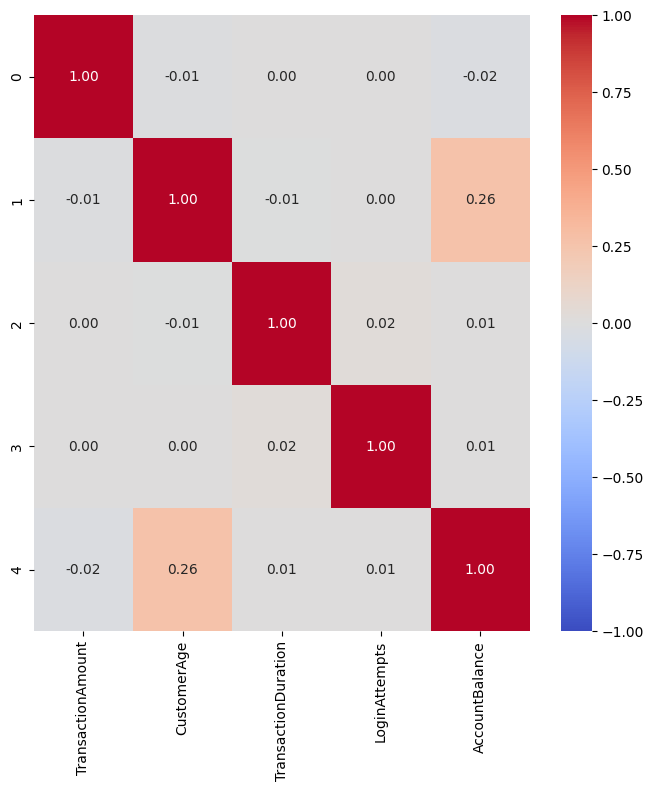

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt

# percobaan pada hotmap, kalau indexnya pakai angka, bukan teks
plt.figure(figsize=(8, 8))
sns.heatmap(kendall_corelation.reset_index().drop(columns='index'), cmap='coolwarm', annot=True, fmt='.2f', vmin=-1)
plt.show()

In [114]:
df = pd.DataFrame({
    "name": ["Ultron", "Ego", "Jarvis", "Friday", "Anon"],
    "age": [0.1, None,  10, 2, None]
})

print()
print(df)

filtered_df = df[df["age"] > 2]
print()
print(filtered_df)

df_null_checked = df.isnull()
non_null_rows_index = df_null_checked[df_null_checked['age'] == False].index
print()
print(df.loc[non_null_rows_index])


     name   age
0  Ultron   0.1
1     Ego   NaN
2  Jarvis  10.0
3  Friday   2.0
4    Anon   NaN

     name   age
2  Jarvis  10.0

     name   age
0  Ultron   0.1
2  Jarvis  10.0
3  Friday   2.0


## Operasi Agregasi

In [115]:
df.groupby("age").aggregate(["count"])

,name
,count
age,
0.1,1
2.0,1
10.0,1


## Hapus baris yang punya data hilang atau duplikat

In [116]:
df.drop_duplicates()
df.dropna()

,name,age
0,Ultron,0.1
2,Jarvis,10.0
3,Friday,2.0


In [180]:
import numpy as np
np.array([1, 2, 3, 4, 5, 6]).reshape(6, 1)

anu = []
anu.append([20, 30])
anu.append([10, 60])
print(anu)

[[20, 30], [10, 60]]
